# Autoemcoder (amomaly detector)

In [1]:
import os
os.chdir('..')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, LeakyReLU, BatchNormalization, Lambda, Concatenate
from tensorflow.keras.models import Model,load_model
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing import image
from tensorflow.keras.losses import binary_crossentropy 

from sklearn.preprocessing import LabelEncoder

In [3]:
import zipfile

with zipfile.ZipFile("data/faces.zip", 'r') as zip_ref:
    zip_ref.extractall("data/faces")

In [4]:
path_smile="data/labels/SMILE_list.txt"
path_nonSmile="data/labels/NON-SMILE_list.txt"

try:
    with open(path_smile, 'r') as f:
        files_smile = []
        for line in f:
            line.strip()
            line=line[:-4]+"ppm"
            files_smile.append(line)
except FileNotFoundError:
    print(f"Error: The file '{path_smile}' was not found.")

try:
    with open(path_nonSmile, 'r') as f:
        files_nonSmile = []
        for line in f:
            line.strip()
            line=line[:-4]+"ppm"
            files_nonSmile.append(line)
except FileNotFoundError:
    print(f"Error: The file '{path_nonSmile}' was not found.")

In [5]:
rootpath = "data/faces/" 

n = 600 
target_size = (200,200) 

imgs_smile = [] 
imgs_nonSmile = [] 

for i in range(n):
    img2 = image.load_img(rootpath + files_smile[i], target_size=target_size)
    img2 = image.img_to_array(img2)
    img2 = img2/255.
    imgs_smile.append(img2)

    img = image.load_img(rootpath + files_nonSmile[i], target_size=target_size)
    img = image.img_to_array(img)
    img = img/255.
    imgs_nonSmile.append(img)

imgs_smile=np.array(imgs_smile)
imgs_nonSmile=np.array(imgs_nonSmile)

# shuffle images
np.random.seed(123)
idxs = np.random.choice(n, size=n, replace=False)
imgs_smile = imgs_smile[idxs,:,:,:]
imgs_nonSmile = imgs_nonSmile[idxs,:,:,:]

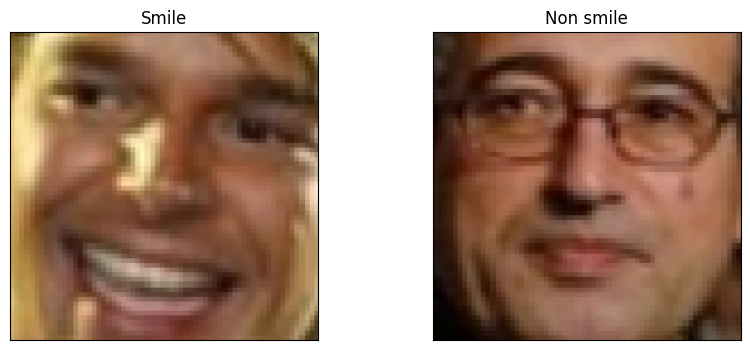

In [6]:
selected = 10
plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
plt.imshow(imgs_smile[selected,])
ax.set_title('Smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ax = plt.subplot(1, 2, 2)
plt.imshow(imgs_nonSmile[selected,])
ax.set_title('Non smile')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.show()

In [33]:
test_split=0.2
n_test = int(n*test_split)

train_smile = imgs_smile[n_test:,:,:,:]
train_nonSmile = imgs_nonSmile[n_test:,:,:,:]

test_smile = imgs_smile[0:n_test,:,:,:]
test_nonSmile = imgs_nonSmile[0:n_test,:,:,:]

test_features=np.concatenate((test_smile, test_nonSmile), axis=0)
test_labels=np.concatenate((np.full(n_test, "smile"), np.full(n_test, "non-smile")))

idxs = np.random.choice(n_test*2, size=n_test*2, replace=False)
test_features = test_features[idxs,:,:,:]
test_labels = test_labels[idxs]

In [34]:
train_nonSmile.shape

(480, 200, 200, 3)

In [35]:
test_features.shape

(240, 200, 200, 3)

In [12]:
le = LabelEncoder()
test_labels_int = le.fit_transform(test_labels) #smile=1, non-smile=0

In [13]:
print(test_labels[0])
print(test_labels_int[0])

smile
1


In [20]:

def combined_loss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)

    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted=brightness**2
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * weighted)

    l1 = tf.reduce_mean(weighted_error)
    return 0.0*bce + 1.0*l1

def add_sobel_channels(x):
    edges = tf.image.sobel_edges(x)   # (B, 200, 200, 2, 3)
    shape = tf.shape(edges)
    # flatten last two dims: 2*3 = 6 channels
    edges = tf.reshape(edges, (shape[0], shape[1], shape[2], 6))
    return edges

input_img = Input(shape=(200, 200, 3))

edges = Lambda(add_sobel_channels)(input_img)
x = Concatenate(axis=-1)([input_img, edges])

x = Conv2D(9, 7, strides=2, padding='same')(x)
x = LeakyReLU()(x)
x = Conv2D(16, 5, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(32, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(64, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = Conv2D(128, 3, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

encoded = Conv2D(128, 3, strides=2, padding='same')(x)
encoded = LeakyReLU(name="encoded")(encoded)

x = Conv2D(128, (3, 3), activation='leaky_relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='leaky_relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='leaky_relu')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='leaky_relu')(x) 
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation='leaky_relu', padding='same')(x) 
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer=optimizers.Adam(),#1e-3
                    loss=combined_loss,
                    metrics=["mae", "mse"])

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 200, 200,  │          0 │ input_layer_1[0]… │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 200,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 9)                │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 100, 100,  │      3,978 │ concatenate_1[0]… │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 100, 100,  │          0 │ conv2d_12[0][0]   │
│ (LeakyReLU)         │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 50, 50,    │      3,616 │ leaky_re_lu_5[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │         64 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 25, 25,    │      4,640 │ leaky_re_lu_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 25, 25,    │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 25, 25,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 13, 13,    │     18,496 │ leaky_re_lu_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 13, 13,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ leaky_re_lu_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                 

 Total params: 351,389 (1.34 MB)

 Trainable params: 350,909 (1.34 MB)

 Non-trainable params: 480 (1.88 KB)

In [21]:
history = autoencoder.fit(train_nonSmile, train_nonSmile,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.15)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.1842 - mae: 0.1214 - mse: 0.0256 - val_loss: 0.2412 - val_mae: 0.1698 - val_mse: 0.0442
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step - loss: 0.1203 - mae: 0.0800 - mse: 0.0116 - val_loss: 0.2398 - val_mae: 0.1742 - val_mse: 0.0460
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 728ms/step - loss: 0.1089 - mae: 0.0725 - mse: 0.0096 - val_loss: 0.2146 - val_mae: 0.1571 - val_mse: 0.0388
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 710ms/step - loss: 0.1125 - mae: 0.0758 - mse: 0.0101 - val_loss: 0.2260 - val_mae: 0.1656 - val_mse: 0.0413
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 711ms/step - loss: 0.1043 - mae: 0.0691 - mse: 0.0086 - val_loss: 0.1990 - val_mae: 0.1459 - val_mse: 0.0338
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 720ms/step - loss: 0.0965 - mae: 0.0638 - mse: 0.0075 - val_loss: 0.2002 - val_mae: 0.1456 - val_mse: 0.0331
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 697ms/step - loss: 0.0922 - mae: 0.0620 - mse: 0.0071

In [22]:
autoencoder.save("model/autoencoder1.keras")

In [18]:
#autoencoder.save("model/autoencoder.keras")
#autoencoder = load_model("model/autoencoder.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step


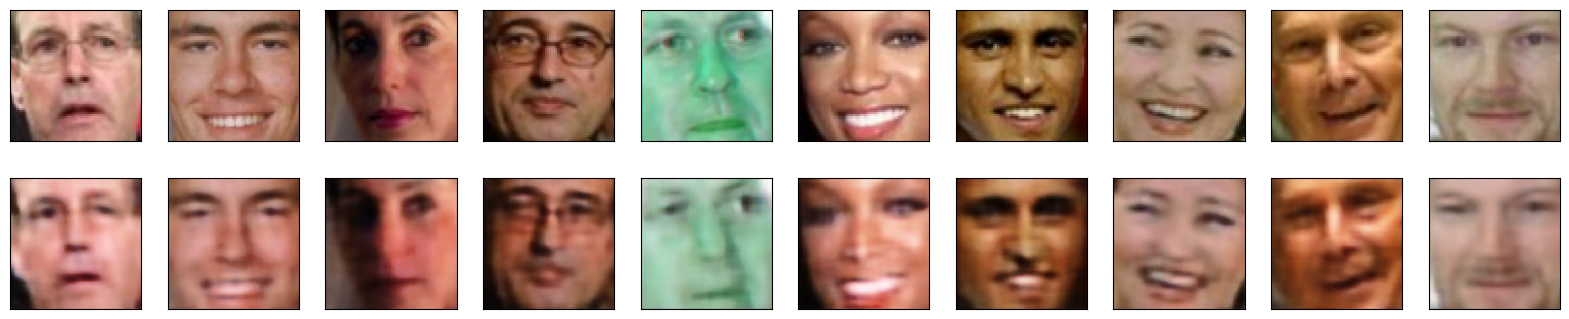

In [23]:
m = 10

decoded_imgs = autoencoder.predict(test_features[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(test_features[i+1].reshape(test_features.shape[1], test_features.shape[2], test_features.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(test_features.shape[1], test_features.shape[2], test_features.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


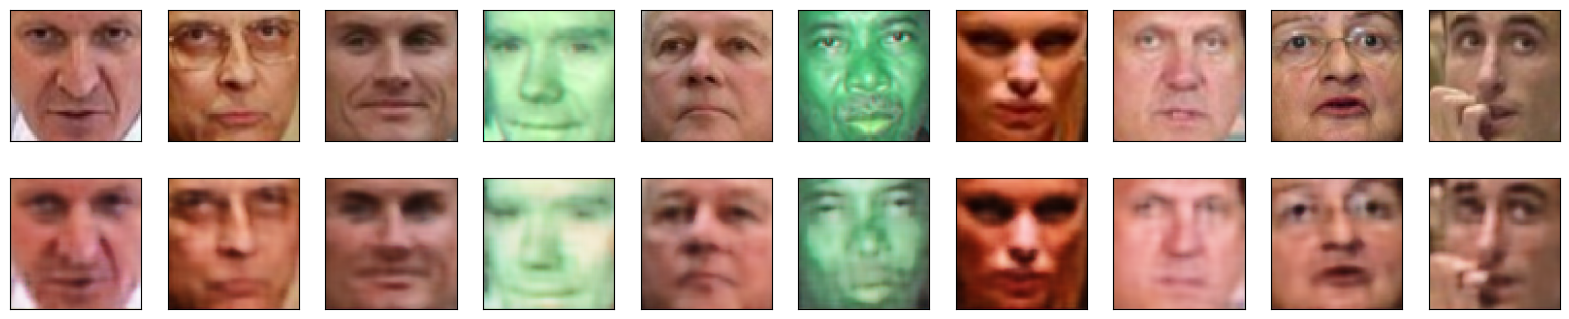

In [24]:
m = 10

decoded_imgs = autoencoder.predict(train_nonSmile[1:m+1,])

plt.figure(figsize=(20, 4))
for i in range(m):
    # display original
    ax = plt.subplot(2, m, i + 1)
    plt.imshow(train_nonSmile[i+1].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, m, i + 1 + m)
    plt.imshow(decoded_imgs[i].reshape(train_nonSmile.shape[1], train_nonSmile.shape[2], train_nonSmile.shape[3]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

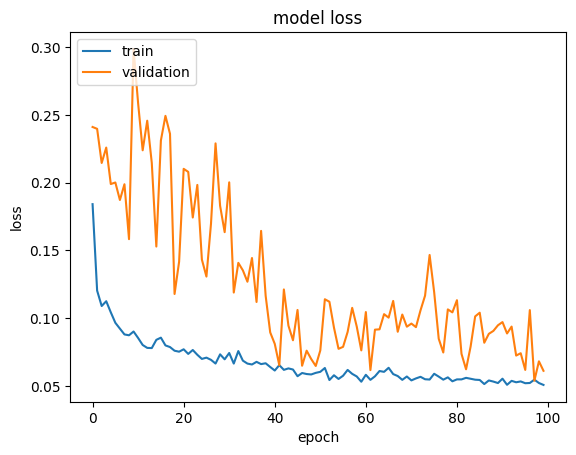

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [36]:
# Evaluate the model on the train set and print the loss.
autoencoder.evaluate(train_nonSmile, train_nonSmile) # [loss]

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.0576 - mae: 0.0382 - mse: 0.0025


[0.057570572942495346, 0.03820420429110527, 0.0025073292199522257]

In [37]:
autoencoder.evaluate(test_nonSmile, test_nonSmile)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - loss: 0.0602 - mae: 0.0398 - mse: 0.0027


[0.060179319232702255, 0.039824943989515305, 0.0027476048562675714]

In [38]:
def combined_loss(y_true, y_pred):
    # BCE + L1 
    bce = tf.reduce_mean(binary_crossentropy(y_true, y_pred), axis=[1,2])

    brightness = tf.reduce_mean(y_true, axis=-1, keepdims=True)
    weighted_error = tf.abs(y_true - y_pred) * (1 + 2 * brightness)
    
    l1 = tf.reduce_mean(weighted_error, axis=[1,2,3])
    return (0.0*bce + 1.0*l1).numpy()

In [39]:
# Make predictions on the train set.
predictions = autoencoder.predict(train_nonSmile)
train_nonSmile_errors = combined_loss(train_nonSmile,predictions)
threshold = train_nonSmile_errors.mean() + 1 * train_nonSmile_errors.std()
print(threshold)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step
0.08828555


In [40]:
print(np.mean(train_nonSmile_errors))

quantiles = np.quantile(train_nonSmile_errors, [0.0, 0.25, 0.50, 0.75, .90, 1.0])
print(quantiles)

0.0744107
[0.04066071 0.06532769 0.07331509 0.08216532 0.08898994 0.14238328]


In [59]:
threshold = 0.08
test_predictions = autoencoder.predict(test_features)
test_errors = combined_loss(test_features,test_predictions)
test_labels_predictions = np.where(np.array(test_errors) > threshold, 1, 0)

print(test_errors[0:10])
print(test_labels_predictions[0:10])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
[0.08301444 0.06595383 0.08650675 0.06333941 0.08157618 0.08714307
 0.09352233 0.08287007 0.06551978 0.09094565]
[1 0 1 0 1 1 1 1 0 1]


In [60]:
predictions_str = le.inverse_transform(test_labels_predictions)
pd.crosstab(test_labels, predictions_str, rownames=['True labels'], colnames=['Predicted labels'])

Predicted labels,non-smile,smile
True labels,,
non-smile,73,47
smile,48,72
